# Hierarchical Clustering

Hierarchical clustering is an unsupervised machine learning algorithm used to group similar data points into clusters without requiring predefined labels.

Unlike, KMeans, where you must specify the number of clusters beforehand, Hierarchical clustering creates a hierarchy (tree like structure) of clusters, allowing you to decide the number of clusters later.

## Types of Hierarchical clustering

- Agglomerative clustering(Bottom-up approch)
- Divisive clustering(Top-Down)

### Agglomerative Clustering

Starts with each data point as and individual cluster.

Then: 

- Merge closest clusters.
- Continue merging.
- until only one cluster remains.


### Divisive clustering

Starts with one cluster containing all points.

Then:

- Split cluster into small clusters
- Continue splitting
- Until each point become its own cluster.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram,linkage

In [2]:
data = {
    "Income":[20,22,25,80,82,85],
    "Score":[25,28,30,85,88,90]
}

df = pd.DataFrame(data)

### Linkage Method

After calculating distances ,we need a rule to merge clusters

This rule is called Linkage

- Single Linkage
- Complete Linkage
- Average Linkage
- Ward Linkage

#### Single Linkage

Uses minimum distance between clusters.

#### Complete Linkage

Uses maximum distance between clusters.

#### Average Linkage

Uses average distances.

#### Ward Linkage

Instead of direct distance, Ward minimizes increase in variance after merging

In [4]:
Z = linkage(
    df,
    method="ward"
)

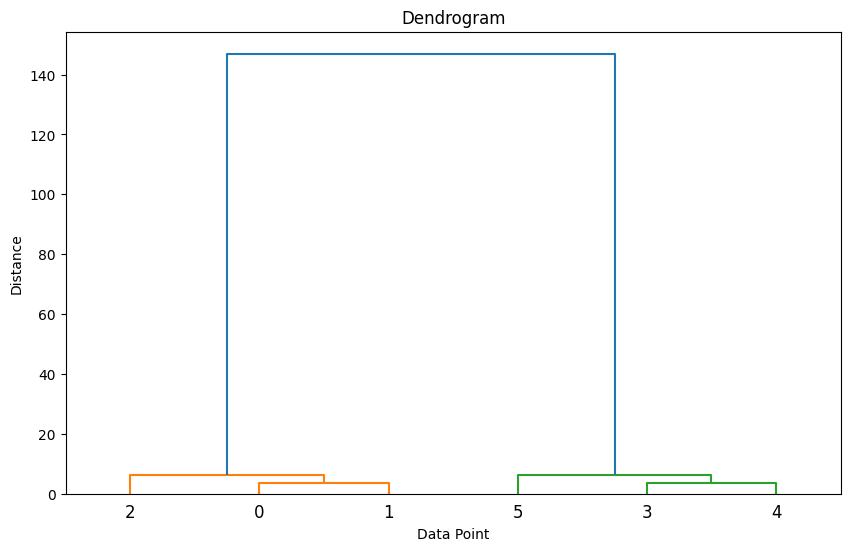

In [5]:
plt.figure(figsize=(10,6))

dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Data Point")
plt.ylabel("Distance")

plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering



In [10]:
wine = load_wine()

X = pd.DataFrame(wine.data,columns=wine.feature_names)
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [11]:
X.shape

(178, 13)

In [12]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
Z = linkage(X_scaled,method='ward')

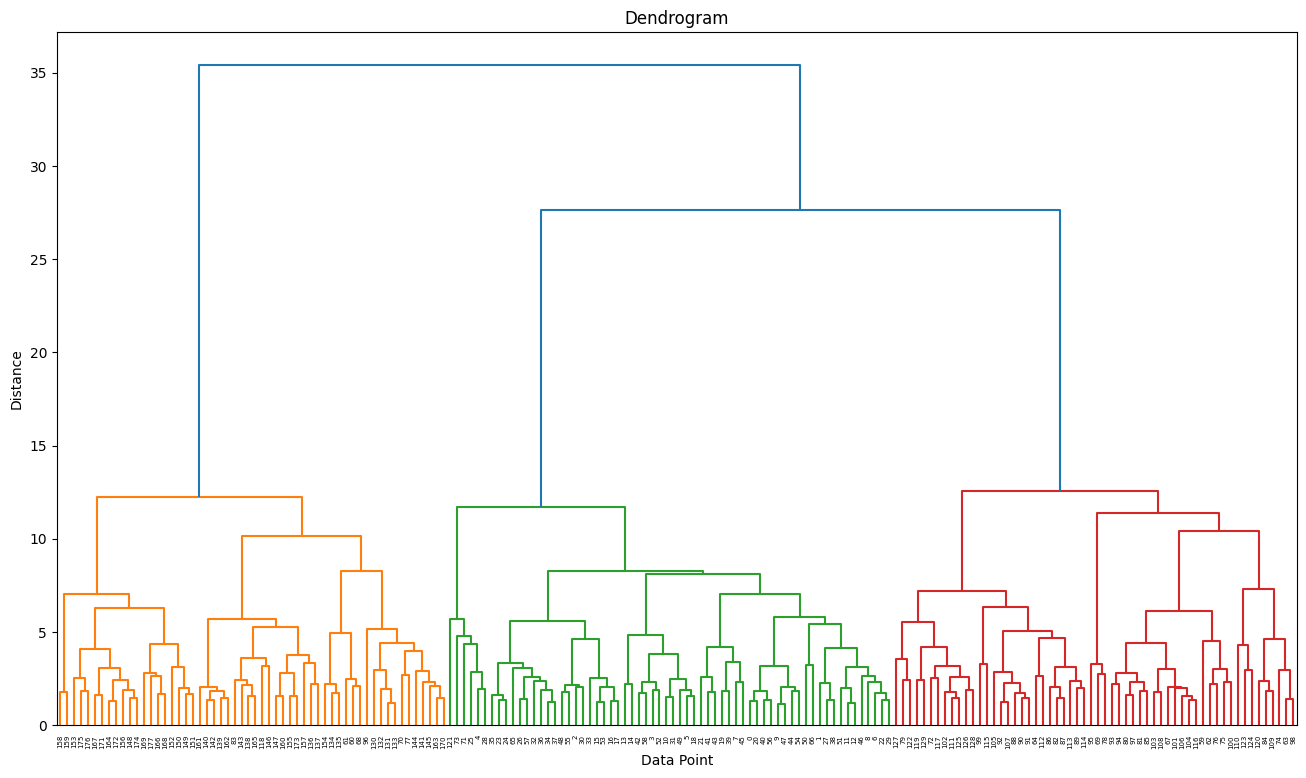

In [15]:
plt.figure(figsize=(16,9))

dendrogram(Z)

plt.title("Dendrogram")
plt.xlabel("Data Point")
plt.ylabel("Distance")

plt.show()

In [21]:
model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

clusters = model.fit_predict(X_scaled)

In [22]:
X['Cluster'] = clusters

In [23]:
X['Cluster'].value_counts()

Cluster
0    122
1     56
Name: count, dtype: int64